In [1]:
import glob
import os.path as op
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import Patch
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression as LOR
from sklearn.model_selection import KFold, cross_val_score
import matplotlib.gridspec as gridspec
from generalized_contrastive_PCA import gcPCA

plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
})

In [2]:
ch_labels = ['STN_L1', 'STN_L2', 'STN_L3', 'STN_L4', 'STN_R1', 'STN_R2', 'STN_R3', 'STN_R4', 'F3', 'Fz', 'F4', 'C3', 'C4', 'Cz']

In [3]:
data_dir = 'C:/user-link/Documents/data/preprocessed_data/'
out_path = 'C:/user-link/Documents/data/derivatives/'
LOR_path = 'C:/user-link/Documents/data/LOR_scores'
data_files = glob.glob(op.join(data_dir, 'dataClean_step1_*_MED_ON.mat'))
subjects = sorted([x.split('/')[-1].split('_')[3] for x in data_files])
print(subjects)

['s02', 's04', 's05', 's06', 's07', 's08', 's10', 's15', 's16', 's17', 's18']


In [4]:
all_bursts = {
    'subject': [],
    'med': [],
    'channel': [],
    'trial': [],
    'waveform': np.zeros((0,132)),
    'waveform_times': [],
    'peak_freq': [],
    'peak_amp_iter': [],
    'peak_amp_base': [],
    'peak_time': [],
    'peak_adjustment': [],
    'fwhm_freq': [],
    'fwhm_time': [],
    'polarity': [],
}

for subject in subjects:
    fname = op.join(out_path, 'beta', f'bursts_{subject}.pickle')
    if op.exists(fname):
        # print(subject)
        with open(fname,'rb') as file:  # rb = read binary
            bursts = pickle.load(file)
        
        # stn_c_bursts = boolean containing True for STNs and C3, C4 and False for every other channels
        stn_c_bursts = np.char.startswith(bursts['channel'].astype(str), 'STN') | (bursts['channel']=='C3') | (bursts['channel']=='C4')
        
        # Loads the data from bursts to all_bursts
        for key in bursts.keys():
            if key=='waveform_times':
                all_bursts[key] = bursts[key]

            elif key=='waveform':
                all_bursts[key] = np.vstack([all_bursts[key], bursts[key][stn_c_bursts, :]])

            else:
                all_bursts[key] = np.hstack([all_bursts[key], bursts[key][stn_c_bursts]])

print(all_bursts['subject'])

['s02' 's02' 's02' ... 's18' 's18' 's18']


In [5]:
for subject in subjects:
    subj_idx = (all_bursts['subject']==subject)
    off_med_trials = np.unique(all_bursts['trial'][subj_idx & (all_bursts['med']=='OFF')])
    max_off_trial = np.max(off_med_trials)
    on_med_idx = subj_idx & (all_bursts['med']=='ON')
    all_bursts['trial'][on_med_idx] = all_bursts['trial'][on_med_idx] + max_off_trial + 1 

In [6]:
c_idx = (all_bursts['channel']=='C3') | (all_bursts['channel']=='C4')
stn_idx = [ch.startswith('STN') for ch in all_bursts['channel']]

burst_times = all_bursts['waveform_times'] * 1000 

on_idx = (all_bursts['med']=='ON')
off_idx = (all_bursts['med']=='OFF')
on_c_idx = c_idx & on_idx
off_c_idx = c_idx & off_idx
on_stn_idx = stn_idx & on_idx
off_stn_idx = stn_idx & off_idx

In [ ]:
# Scale waveforms within subject such as (X - median)/IQR 
scaled_waveforms = np.zeros_like(all_bursts['waveform'])

for subject in np.unique(all_bursts['subject']):
    subj_idx = (all_bursts['subject'] == subject)
    scaler = RobustScaler().fit(all_bursts['waveform'][subj_idx])                       # .fit() returns the median and IQR values
    scaled_waveforms[subj_idx, :] = scaler.transform(all_bursts['waveform'][subj_idx])  # .transform() does the maths.

: 

In [ ]:
# gcpca_model = gcPCA(method='v4', normalize_flag=False)

# c_gcpca_model = gcPCA(method='v4', normalize_flag=False)                                # gcPCA model creation
# c_gcpca_model.fit(scaled_waveforms[off_c_idx, :], scaled_waveforms[on_c_idx, :])        # gcPCA application on OFF/ON cortex

# stn_gcpca_model = gcPCA(method='v4', normalize_flag=False)                              # gcPCA model creation
# stn_gcpca_model.fit(scaled_waveforms[off_stn_idx, :], scaled_waveforms[on_stn_idx, :])  # gcPCA application on OFF/ON STN

In [ ]:
# # Now, fit the models on the pooled, subject-scaled data
# on_bursts = scaled_waveforms[on_idx, :]
# off_bursts = scaled_waveforms[off_idx, :]
# gcpca_model.fit(off_bursts, on_bursts)

# # Project all bursts into PC space
# all_scores = np.zeros((all_bursts['waveform'].shape[0], gcpca_model.loadings_.shape[1]))
# all_scores[off_idx, :] = gcpca_model.Ra_scores_
# all_scores[on_idx, :] = gcpca_model.Rb_scores_

In [14]:
test_subject = np.random.choice(subjects)
train_subjects = [subj for subj in subjects if subj != test_subject]
test_subject = [str(test_subject)]
print(f'Test subject: {test_subject}')
print(f'Train subjects: {train_subjects}')

Test subject: ['s17']
Train subjects: ['s02', 's04', 's05', 's06', 's07', 's08', 's10', 's15', 's16', 's18']


In [23]:
n_bins = 4  # Number of bins to use for each gcPC
cols = [0, 1, -2, -1]  # List of gcPC columns to consider

X, y = [], []
pc_bin_lims = np.zeros((len(cols), n_bins + 1))
trials = np.unique(all_bursts['subject'])

# Build subject-level feature matrix X and matching label vector y
for subj in train_subjects:
    # For each trial, count how many bursts fall into each bin for the current gcPC
    burst_idx = all_bursts['subject']==subj
    label = np.unique(all_bursts['med'][burst_idx])[0] and np.unique(all_bursts['med'][burst_idx])[1]

    row = []
    for i, col in enumerate(cols):
        # Compute percentile edges for each gcPC of interest across all bursts 
        pc_bin_lims[i, :] = np.percentile(all_scores[:, col], np.linspace(0, 100, n_bins + 1))

        for idx in range(len(pc_bin_lims[i, :]) - 1):
            # Count bursts whose gcPC score falls within the current percentile bin
            count = len(np.where((all_scores[burst_idx, cols[i]] >= pc_bin_lims[i, idx]) & (all_scores[burst_idx, cols[i]] < pc_bin_lims[i, idx+1]))[0])
            row.append(count)

    X.append(row)
    y.append(0 if label=='OFF' else 1)

X = np.array(X)
y = np.array(y)

model = LOR()
model = model.fit(X, y)
y_pred = model.predict(X)

rmse = np.sqrt(np.mean((y - y_pred) ** 2))
print(rmse)

ValueError: This solver needs samples of at least 2 classes in the data, but the data contains only one class: np.int64(1)

In [19]:
print("Unique med values:", np.unique(all_bursts['med'], return_counts=True))
print("y distribution:", np.unique(y, return_counts=True))

Unique med values: (array(['OFF', 'ON'], dtype='<U32'), array([15206, 14128]))
y distribution: (array([1]), array([10]))


In [30]:
X

array([[ 406,  817,  898,  429,  414,  826,  867,  443,  493,  624,  759,
         674,  586,  844,  713,  407],
       [1170,  234,  230, 1106, 1134,  241,  220, 1145,  679,  786,  685,
         590,  697,  664,  732,  647],
       [ 255,  881, 1056,  430,  364,  857, 1035,  366,  598,  740,  799,
         485,  664,  661,  692,  605],
       [ 715,  786,  829,  633,  749,  848,  686,  680,  493,  847,  989,
         634,  510,  919,  924,  610],
       [ 518,  859,  740,  450,  424,  797,  877,  469,  600,  694,  639,
         634,  819,  621,  563,  564],
       [ 457,  748,  748,  538,  549,  784,  688,  470,  711,  654,  532,
         594,  489,  754,  701,  547],
       [ 353,  944,  964,  336,  293,  992,  988,  324,  316,  728,  982,
         571,  369,  814,  934,  480],
       [1498,  143,  150, 1462, 1497,  162,  135, 1459,  923,  908,  748,
         675,  744,  847,  915,  748],
       [ 460, 1152,  925,  325,  344, 1029, 1046,  443,  521,  943,  808,
         590,  724,  6

In [31]:
y

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [ ]:
for trial in trials:
    # For each trial, count how many bursts fall into each bin for the current gcPC
    burst_idx = all_bursts['subject']==trial
    label = np.unique(all_bursts["med"][burst_idx])[0]

    print(label)

OFF
OFF
OFF
OFF
OFF
OFF
OFF
OFF
OFF
OFF
OFF


In [ ]:
scaler = RobustScaler()
X = scaler.fit_transform(X)
n_splits = 10  # Number of folds for cross-validation

# K-Fold cross-validation splitter: Shuffles data before splitting into folds. 
# ```random_state``` ensures reproducibility.
cv = KFold(n_splits=n_splits, shuffle=True, random_state=6)

# Compute accuracy per fold. 
# ```cross_val_score``` clones and fits the estimator inside each fold.
scores = cross_val_score(
    model, X, y, scoring='accuracy', cv=cv, n_jobs=-1
)

print(f"Accuracy: {np.mean(scores):.3f}, \nSTD: {np.std(scores):.3f}, \nScore: {scores}")

Accuracy: 0.930, 
STD: 0.108, 
Score: [0.8  1.   1.   1.   0.75 1.   1.   1.   1.   0.75]


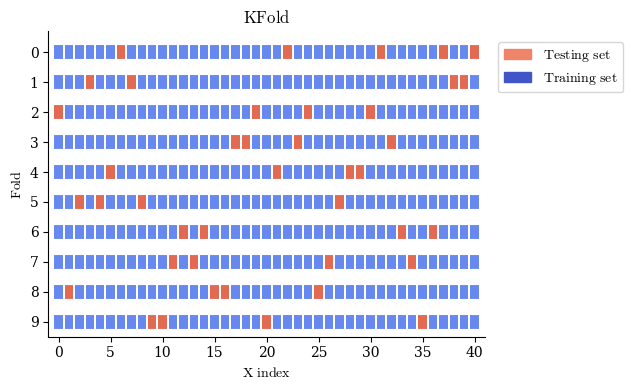

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
plot_kfold(cv, X, y, ax, n_splits, xlim_max=len(X))
plt.tight_layout()
fig.subplots_adjust(right=0.7)
plt.show()